# Predictions for Industry Stabilizers — k-value Estimation
## Using Trained Models from Notebook 1 (Radical) & Notebook 2 (Cluster)

---

**Molecules**: Irganox 1098 · Tinuvin 123 · Tinuvin 326 · Tinuvin 770

**Approach**:
- Load the trained pipeline from `radical_pipeline.pkl` (Notebook 1: SMILES-BERT + CalcDesc + QM + OHE Radical)
- Load the trained pipeline from `cluster_pipeline.pkl` (Notebook 2: CalcDesc + QM, cluster-based)
- Compute features for 4 new molecules using the **same preprocessing as training**
- Predict log₁₀(k) for each radical type → convert to k_value
- Ensemble both models for final result


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, csv
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem, MACCSkeys, DataStructs
from rdkit.Chem import Fragments as RDKitFrags
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

def canonicalize(smi):
    mol = Chem.MolFromSmiles(str(smi).strip())
    return Chem.MolToSmiles(mol) if mol else None

print('Imports OK')


Imports OK


---
## 1. New Molecules

,MW,LogP,HBD,HBA,TPSA
Name,,,,,
Irganox 1098,637.0,8.65,4,4,98.7
Tinuvin 123,737.2,11.82,0,8,77.5
Tinuvin 326,315.8,4.39,1,3,50.9
Tinuvin 770,480.7,5.81,2,6,76.7


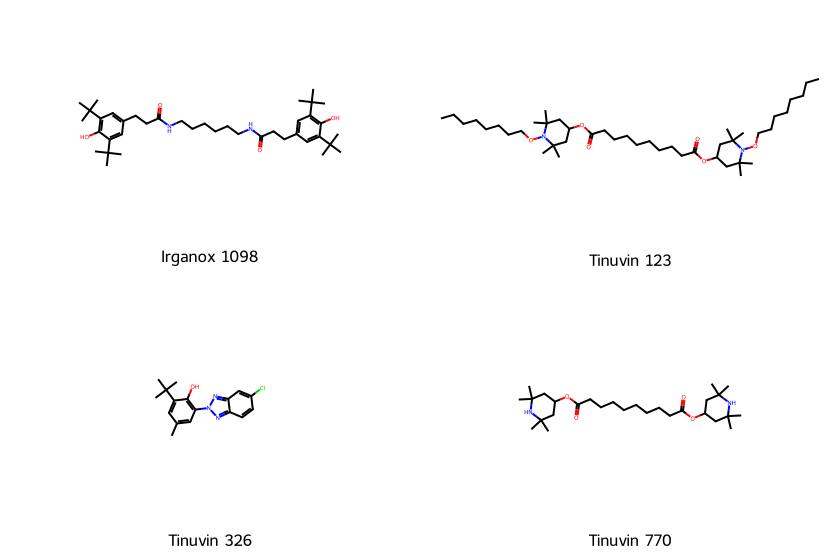

In [2]:
NEW_MOLECULES = {
    'Irganox 1098': 'CC(c1c(c(cc(c1)CCC(=O)NCCCCCCNC(=O)CCc2cc(c(c(c2)C(C)(C)C)O)C(C)(C)C)C(C)(C)C)O)(C)C',
    'Tinuvin 123' : 'CCCCCCCCON1C(CC(CC1(C)C)OC(=O)CCCCCCCCC(=O)OC2CC(N(C(C2)(C)C)OCCCCCCCC)(C)C)(C)C',
    'Tinuvin 326' : 'CC1=CC(=C(C(=C1)N2N=C3C=CC(=CC3=N2)Cl)O)C(C)(C)C',
    'Tinuvin 770' : 'CC1(CC(CC(N1)(C)C)OC(=O)CCCCCCCCC(=O)OC2CC(NC(C2)(C)C)(C)C)C',
}
new_names  = list(NEW_MOLECULES.keys())
new_smiles = list(NEW_MOLECULES.values())
mols_rdkit = {n: Chem.MolFromSmiles(s) for n, s in NEW_MOLECULES.items()}

info_rows = []
for name, mol in mols_rdkit.items():
    info_rows.append({'Name': name, 'MW': round(Descriptors.MolWt(mol),1),
                      'LogP': round(Descriptors.MolLogP(mol),2),
                      'HBD': Descriptors.NumHDonors(mol),
                      'HBA': Descriptors.NumHAcceptors(mol),
                      'TPSA': round(Descriptors.TPSA(mol),1)})
display(pd.DataFrame(info_rows).set_index('Name'))
img = Draw.MolsToGridImage(list(mols_rdkit.values()), molsPerRow=2,
                            subImgSize=(420, 280), legends=new_names)
display(img)


---
## 2. Load Trained Pipelines

In [3]:
# Load pipelines saved by Notebook 1 and Notebook 2
radical_pipeline = joblib.load('radical_pipeline.pkl')
cluster_pipeline = joblib.load('cluster_pipeline.pkl')

print('radical_pipeline.pkl loaded:')
print(f'  Model      : {radical_pipeline["best_model_name"]}')
print(f'  Feature set: {radical_pipeline["best_repr"]}')
print(f'  Test R²    : {radical_pipeline["test_r2"]:.4f}')
print(f'  Radical cats: {radical_pipeline["radical_cats"]}')
print()
print('cluster_pipeline.pkl loaded:')
print(f'  Model      : {cluster_pipeline["best_model_name"]}')
print(f'  Feature set: {cluster_pipeline["best_repr"]}')
print(f'  Test R²    : {cluster_pipeline["test_r2"]:.4f}')
print(f'  Clusters   : {cluster_pipeline["unique_clusters"]}')


radical_pipeline.pkl loaded:
  Model      : SVR (RBF)
  Feature set: SVD64_BERT+rest+OHE
  Test R²    : 0.8782
  Radical cats: ['RO2*', 'sec-RO2*', 'tert-RO2*']

cluster_pipeline.pkl loaded:
  Model      : KNN
  Feature set: CalcDesc+QM
  Test R²    : 0.8447
  Clusters   : [np.int64(1), np.int64(2), np.int64(3)]


---
## 3. Feature Computation for New Molecules

Using the **same preprocessing pipeline** (same imputer, column mask, scalers) as during training.

In [4]:
# ── Compute CalcDesc + Fragments (same column set as training) ───────────────
_frag_names = sorted([n for n in dir(RDKitFrags)
                      if n.startswith('fr_') and callable(getattr(RDKitFrags, n))])

def compute_calcdesc_full(smiles_list):
    desc_rows, frag_rows, desc_names = [], [], None
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            d = Descriptors.CalcMolDescriptors(mol)
            if desc_names is None: desc_names = list(d.keys())
            desc_rows.append(list(d.values()))
            frag_rows.append([getattr(RDKitFrags, fn)(mol) for fn in _frag_names])
        else:
            n_d = len(desc_names) if desc_names else 1
            desc_rows.append([np.nan]*n_d)
            frag_rows.append([np.nan]*len(_frag_names))
    X = np.hstack([np.array(desc_rows, dtype=np.float64),
                   np.array(frag_rows,  dtype=np.float64)])
    return np.where(np.isinf(X), np.nan, X)

X_new_raw = compute_calcdesc_full(new_smiles)
print(f'Raw CalcDesc+Fragments for new molecules: {X_new_raw.shape}')


Raw CalcDesc+Fragments for new molecules: (4, 302)


In [5]:
# ── Apply training column mask & imputer (Radical pipeline) ─────────────────
col_mask_rad  = radical_pipeline['col_mask']
imputer_rad   = radical_pipeline['imputer_calcdesc']
X_new_cd_rad  = imputer_rad.transform(X_new_raw[:, col_mask_rad]).astype(np.float32)

# QM — impute with training medians (no QM data for new molecules)
qm_imputer_rad = radical_pipeline['qm_imputer']
qm_med_rad     = qm_imputer_rad.statistics_    # training medians [HOMO, LUMO, Gap]
X_new_qm_rad   = np.tile(qm_med_rad, (len(new_names), 1)).astype(np.float32)

# ── Apply training column mask & imputer (Cluster pipeline) ─────────────────
col_mask_clu  = cluster_pipeline['col_mask']
imputer_clu   = cluster_pipeline['imputer_calcdesc']
X_new_cd_clu  = imputer_clu.transform(X_new_raw[:, col_mask_clu]).astype(np.float32)

qm_imputer_clu = cluster_pipeline['qm_imputer']
qm_med_clu     = qm_imputer_clu.statistics_
X_new_qm_clu   = np.tile(qm_med_clu, (len(new_names), 1)).astype(np.float32)

print(f'Radical pipeline CalcDesc: {X_new_cd_rad.shape}  QM: {X_new_qm_rad.shape}')
print(f'Cluster pipeline CalcDesc: {X_new_cd_clu.shape}  QM: {X_new_qm_clu.shape}')
print(f'QM imputed (HOMO/LUMO/Gap): {qm_med_rad.round(4).tolist()}')


Radical pipeline CalcDesc: (4, 252)  QM: (4, 3)
Cluster pipeline CalcDesc: (4, 252)  QM: (4, 3)
QM imputed (HOMO/LUMO/Gap): [-5.672599792480469, -0.11699999868869781, 5.433899879455566]


In [6]:
# ── BERT embeddings for new molecules ────────────────────────────────────────
bert_model_id = radical_pipeline['bert_model_id']
X_new_bert = None

try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    print(f'Computing BERT embeddings for {len(new_names)} molecules...')
    tokenizer  = AutoTokenizer.from_pretrained(bert_model_id)
    bert_model = AutoModel.from_pretrained(bert_model_id)
    bert_model.eval()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    bert_model = bert_model.to(device)
    with torch.no_grad():
        enc = tokenizer(new_smiles, padding=True, truncation=True,
                        max_length=512, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        X_new_bert = bert_model(**enc).last_hidden_state[:, 0, :].cpu().numpy().astype(np.float32)
    print(f'BERT embeddings: {X_new_bert.shape}')
except Exception as e:
    print(f'BERT unavailable ({e}). Using CalcDesc+QM only.')


Computing BERT embeddings for 4 molecules...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<?, ?it/s]


RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT embeddings: (4, 768)


---
## 4. Radical Group Model Predictions

Using the pipeline saved by **Notebook 1** for each of the 3 radical types.

In [7]:
# ── Build feature vector for Radical pipeline ────────────────────────────────
def build_radical_features(X_new_bert, X_new_cd_rad, X_new_qm_rad, rad_type):
    rp = radical_pipeline
    cfg = rp['dr_config']
    parts = []

    # DR block (BERT or multi-block)
    if X_new_bert is not None and 'bert' in cfg['dr_block']:
        X_bert_scaled = rp['sc_bert'].transform(X_new_bert)
        if rp['dr_transformer'] is not None:
            if rp['dr_pca_scaler'] is not None:
                X_bert_scaled = rp['dr_pca_scaler'].transform(X_bert_scaled)
            X_bert_dr = rp['dr_transformer'].transform(X_bert_scaled)
        else:
            X_bert_dr = X_bert_scaled
        if cfg['dr_block'] == 'bert':
            parts.append(X_bert_dr)
        # multi-block: add calcdesc+qm to dr block too
        if 'calcdesc' in cfg['dr_block']:
            parts.append(rp['sc_calc'].transform(X_new_cd_rad))
        if 'qm' in cfg['dr_block']:
            parts.append(rp['sc_qm'].transform(X_new_qm_rad))
    elif cfg['method'] == 'raw':
        # Raw block
        if 'bert' in cfg['dr_block'] and X_new_bert is not None:
            parts.append(rp['sc_bert'].transform(X_new_bert))
        if 'calcdesc' in cfg['dr_block']:
            parts.append(rp['sc_calc'].transform(X_new_cd_rad))
        if 'qm' in cfg['dr_block']:
            parts.append(rp['sc_qm'].transform(X_new_qm_rad))

    # Raw append (calcdesc, qm, ohe — never DR'd)
    raw_app = cfg['raw_append']
    if 'calcdesc' in raw_app:
        parts.append(rp['sc_calc'].transform(X_new_cd_rad))
    if 'qm' in raw_app:
        parts.append(rp['sc_qm'].transform(X_new_qm_rad))
    if 'ohe' in raw_app:
        ohe_input = pd.DataFrame({rp['radical_col']: [rad_type]*len(new_names)})
        parts.append(rp['ohe_enc'].transform(ohe_input))

    X_feat = np.hstack(parts).astype(np.float32)
    if rp['needs_scale']:
        X_feat = rp['sc_final'].transform(X_feat)
    return X_feat

radical_types = [c for c in radical_pipeline['radical_cats']] + [radical_pipeline['radical_cats'][0]]
# get all 3 radical types from the OHE categories
all_cats = radical_pipeline['ohe_enc'].categories_[0].tolist()
print('Radical categories:', all_cats)

pred_rad_rows = []
for rad_type in all_cats:
    try:
        X_feat = build_radical_features(X_new_bert, X_new_cd_rad, X_new_qm_rad, rad_type)
        preds  = radical_pipeline['best_model'].predict(X_feat)
        for i, name in enumerate(new_names):
            pred_rad_rows.append({'Molecule': name, 'Radical': rad_type,
                                   'log_k_radical': round(float(preds[i]), 3)})
        print(f'  {rad_type}: predictions done')
    except Exception as e:
        print(f'  {rad_type}: ERROR — {e}')

pred_rad_df = pd.DataFrame(pred_rad_rows)
display(pred_rad_df.pivot(index='Molecule', columns='Radical', values='log_k_radical').round(3))


Radical categories: ['RO2*', 'sec-RO2*', 'tert-RO2*']
  RO2*: predictions done
  sec-RO2*: predictions done
  tert-RO2*: predictions done


Radical,RO2*,sec-RO2*,tert-RO2*
Molecule,,,
Irganox 1098,5.911,5.882,5.774
Tinuvin 123,6.557,6.558,6.554
Tinuvin 326,7.467,7.385,7.088
Tinuvin 770,6.532,6.535,6.512


---
## 5. Cluster Model Predictions

Using the pipeline saved by **Notebook 2**. New molecules are assigned to the nearest structural cluster via KNN.

In [8]:
# ── Assign new molecules to cluster ─────────────────────────────────────────
cp = cluster_pipeline
X_all_new  = np.hstack([X_new_cd_clu, X_new_qm_clu]).astype(np.float32)
X_all_new_sc = cp['sc_knn'].transform(X_all_new)
assigned_clusters = cp['knn_cluster'].predict(X_all_new_sc)

for name, cl in zip(new_names, assigned_clusters):
    print(f'  {name} → Cluster {cl}')

# ── Build feature vector for Cluster pipeline ────────────────────────────────
cfg_clu = cp['dr_config']
parts_clu = []

if cfg_clu['method'] == 'raw':
    if 'calcdesc' in cfg_clu['dr_block']:
        parts_clu.append(cp['sc_calc'].transform(X_new_cd_clu))
    if 'qm' in cfg_clu['dr_block']:
        parts_clu.append(cp['sc_qm'].transform(X_new_qm_clu))
elif cp['dr_transformer'] is not None:
    X_dr_in = np.hstack([
        cp['sc_calc'].transform(X_new_cd_clu) if 'calcdesc' in cfg_clu['dr_block'] else np.empty((len(new_names),0)),
        cp['sc_qm'].transform(X_new_qm_clu) if 'qm' in cfg_clu['dr_block'] else np.empty((len(new_names),0)),
    ]).astype(np.float32)
    if cp['dr_pca_scaler']: X_dr_in = cp['dr_pca_scaler'].transform(X_dr_in)
    parts_clu.append(cp['dr_transformer'].transform(X_dr_in))
    if 'calcdesc' in cfg_clu.get('raw_append',''):
        parts_clu.append(cp['sc_calc'].transform(X_new_cd_clu))
    if 'qm' in cfg_clu.get('raw_append',''):
        parts_clu.append(cp['sc_qm'].transform(X_new_qm_clu))

X_clu_feat = np.hstack(parts_clu).astype(np.float32)
if cp['needs_scale']:
    X_clu_feat = cp['sc_final'].transform(X_clu_feat)

preds_clu = cp['best_model'].predict(X_clu_feat)
pred_clu_df = pd.DataFrame({
    'Molecule': new_names,
    'Assigned Cluster': assigned_clusters,
    'log_k_cluster': [round(float(p), 3) for p in preds_clu]
})
display(pred_clu_df)


  Irganox 1098 → Cluster 1
  Tinuvin 123 → Cluster 3
  Tinuvin 326 → Cluster 1
  Tinuvin 770 → Cluster 3


,Molecule,Assigned Cluster,log_k_cluster
0,Irganox 1098,1,4.827
1,Tinuvin 123,3,7.330
2,Tinuvin 326,1,4.231
3,Tinuvin 770,3,7.430


---
## 6. Final Results — Ensemble Predictions

In [9]:
# ── Ensemble: average Radical model + Cluster model ─────────────────────────
summary_rows = []
for rad_type in all_cats:
    for i, name in enumerate(new_names):
        logk_rad = pred_rad_df[(pred_rad_df['Molecule']==name) &
                               (pred_rad_df['Radical']==rad_type)]['log_k_radical'].values
        logk_clu = pred_clu_df[pred_clu_df['Molecule']==name]['log_k_cluster'].values
        if len(logk_rad) == 0 or len(logk_clu) == 0: continue
        logk_rad_v = float(logk_rad[0])
        logk_clu_v = float(logk_clu[0])
        logk_ens   = round((logk_rad_v + logk_clu_v) / 2, 3)
        summary_rows.append({
            'Molecule'                   : name,
            'Radical Type'               : rad_type,
            'Radical Model log10(k)'     : logk_rad_v,
            'Cluster Model log10(k)'     : logk_clu_v,
            'Ensemble log10(k)'          : logk_ens,
            'Radical Model k [L/mol/s]'  : f'{10**logk_rad_v:.3e}',
            'Cluster Model k [L/mol/s]'  : f'{10**logk_clu_v:.3e}',
            'Ensemble k [L/mol/s]'       : f'{10**logk_ens:.3e}',
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style
    .background_gradient(subset=['Ensemble log10(k)'], cmap='RdYlGn')
    .format({'Radical Model log10(k)': '{:.3f}',
             'Cluster Model log10(k)': '{:.3f}',
             'Ensemble log10(k)':      '{:.3f}'})
)
summary_df.to_csv('stabilizers_k_predictions.csv', index=False)
print('Saved: stabilizers_k_predictions.csv')


,Molecule,Radical Type,Radical Model log10(k),Cluster Model log10(k),Ensemble log10(k),Radical Model k [L/mol/s],Cluster Model k [L/mol/s],Ensemble k [L/mol/s]
0,Irganox 1098,RO2*,5.911,4.827,5.369,8.147e+05,6.714e+04,2.339e+05
1,Tinuvin 123,RO2*,6.557,7.330,6.944,3.606e+06,2.138e+07,8.790e+06
2,Tinuvin 326,RO2*,7.467,4.231,5.849,2.931e+07,1.702e+04,7.063e+05
3,Tinuvin 770,RO2*,6.532,7.430,6.981,3.404e+06,2.692e+07,9.572e+06
4,Irganox 1098,sec-RO2*,5.882,4.827,5.354,7.621e+05,6.714e+04,2.259e+05
5,Tinuvin 123,sec-RO2*,6.558,7.330,6.944,3.614e+06,2.138e+07,8.790e+06
6,Tinuvin 326,sec-RO2*,7.385,4.231,5.808,2.427e+07,1.702e+04,6.427e+05
7,Tinuvin 770,sec-RO2*,6.535,7.430,6.982,3.428e+06,2.692e+07,9.594e+06
8,Irganox 1098,tert-RO2*,5.774,4.827,5.300,5.943e+05,6.714e+04,1.995e+05
9,Tinuvin 123,tert-RO2*,6.554,7.330,6.942,3.581e+06,2.138e+07,8.750e+06


Saved: stabilizers_k_predictions.csv


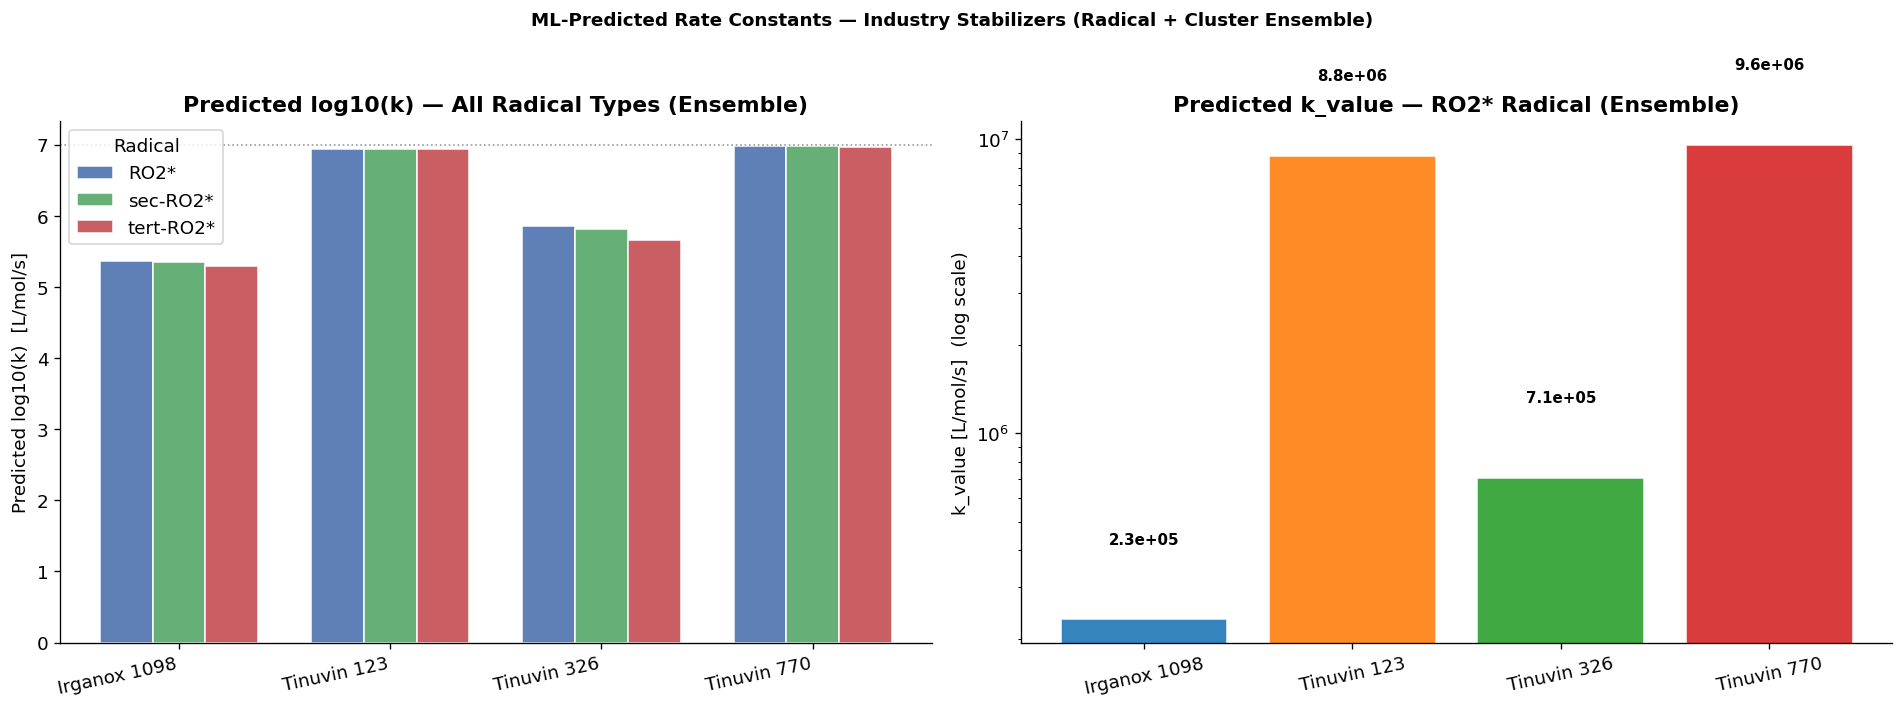

Figure saved: stabilizers_predictions.png


In [10]:
# ── Publication figure ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {'RO2*': '#4C72B0', 'sec-RO2*': '#55A868', 'tert-RO2*': '#C44E52'}
all_cats_sorted = sorted(all_cats)
x = np.arange(len(new_names)); w = 0.25

for j, rad in enumerate(all_cats_sorted):
    sub = summary_df[summary_df['Radical Type']==rad].set_index('Molecule')
    vals = [sub.loc[n,'Ensemble log10(k)'] if n in sub.index else np.nan for n in new_names]
    color = palette.get(rad, '#888888')
    axes[0].bar(x + (j-1)*w, vals, w, label=rad, color=color, edgecolor='white', alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(new_names, rotation=12, ha='right')
axes[0].set_ylabel('Predicted log10(k)  [L/mol/s]')
axes[0].set_title('Predicted log10(k) — All Radical Types (Ensemble)', fontweight='bold')
axes[0].legend(title='Radical'); axes[0].axhline(7, color='black', ls=':', lw=1, alpha=0.4)

# k_value for RO2* on log scale
ro2_sub = summary_df[summary_df['Radical Type']=='RO2*']
k_vals  = [10**v for v in ro2_sub['Ensemble log10(k)']]
colors  = sns.color_palette('tab10', len(new_names))
bars = axes[1].bar(ro2_sub['Molecule'], k_vals, color=colors, edgecolor='white', alpha=0.9)
axes[1].set_yscale('log')
axes[1].set_ylabel('k_value [L/mol/s]  (log scale)')
axes[1].set_title('Predicted k_value — RO2* Radical (Ensemble)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=12)
for bar, kv in zip(bars, k_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, kv*1.8,
                 f'{kv:.1e}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('ML-Predicted Rate Constants — Industry Stabilizers (Radical + Cluster Ensemble)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('stabilizers_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: stabilizers_predictions.png')


---
## 7. Interpretation

| log₁₀(k) range | Reactivity | Antioxidant effectiveness |
|-----------------|------------|--------------------------|
| > 7 | Fast | High — effective radical scavenger |
| 5 – 7 | Moderate | Moderate |
| < 5 | Slow | Limited |

**Notes**:
- HOMO/LUMO/Gap imputed from training set medians (no quantum chemistry calculated for new molecules)
- Radical model: trained on `Clustered.csv` (1206 compounds, 3 radical groups)
- Cluster model: trained on `clustered_molecules.csv` (1212 compounds, 3 structural clusters)
- Cluster assignment: 7-nearest neighbors in CalcDesc feature space
